# Tweet Emotions Classification Notebook

This notebook compares four approaches on the same dataset:

1. From scratch traditional baseline: **TF-IDF + Linear SVM**
2. From scratch deep learning baseline: **BiLSTM**
3. Fine-tuned transformer: **BERTweet**
4. Fine-tuned transformer with metric learning: **BERTweet + Supervised Contrastive Loss**

The dataset is expected to contain:
- `train.csv`
- `val.csv`
- `test.csv`

Each split should have:
- `text`
- `label`

Label mapping used in this notebook:
- `0 = sadness`
- `1 = joy`
- `2 = love`
- `3 = anger`
- `4 = fear`
- `5 = surprise`

In [1]:
# Install packages for the transformer experiments
!pip -q install -U "transformers>=4.46,<5.0" datasets evaluate accelerate emoji sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 58.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.1 MB/s eta 0:00:00


In [2]:
import os
import re
import gc
import json
import random
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [3]:
# Reproducibility utilities
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)
print("Seed set to:", SEED)

Seed set to: 42


In [4]:
# Auto-find the dataset location in Kaggle
def find_dataset_files():
    candidate_roots = [
        Path("/kaggle/input"),
        Path("/kaggle/working"),
        Path("."),
    ]

    # First, try to find CSV files directly
    for root in candidate_roots:
        if root.exists():
            train_matches = list(root.rglob("train.csv"))
            val_matches = list(root.rglob("val.csv"))
            test_matches = list(root.rglob("test.csv"))
            if train_matches and val_matches and test_matches:
                return {
                    "train": train_matches[0],
                    "val": val_matches[0],
                    "test": test_matches[0],
                }

    # Second, try to find a zip file and extract it
    for root in candidate_roots:
        if root.exists():
            zip_matches = list(root.rglob("*.zip"))
            for zip_path in zip_matches:
                extract_dir = Path("/kaggle/working/extracted_dataset")
                extract_dir.mkdir(parents=True, exist_ok=True)
                try:
                    with zipfile.ZipFile(zip_path, "r") as zf:
                        names = set(zf.namelist())
                        if {"train.csv", "val.csv", "test.csv"}.issubset(names):
                            zf.extractall(extract_dir)
                            return {
                                "train": extract_dir / "train.csv",
                                "val": extract_dir / "val.csv",
                                "test": extract_dir / "test.csv",
                            }
                except Exception:
                    pass

    raise FileNotFoundError(
        "Could not find train.csv, val.csv, and test.csv. "
        "Please check your Kaggle input path."
    )

data_files = find_dataset_files()
data_files

{'train': PosixPath('/kaggle/input/datasets/hiteshyadavx/tweet-emotion-recognition/train.csv'),
 'val': PosixPath('/kaggle/input/datasets/hiteshyadavx/tweet-emotion-recognition/val.csv'),
 'test': PosixPath('/kaggle/input/datasets/hiteshyadavx/tweet-emotion-recognition/test.csv')}

In [5]:
# Load the dataset
train_df = pd.read_csv(data_files["train"])
val_df = pd.read_csv(data_files["val"])
test_df = pd.read_csv(data_files["test"])

print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

display(train_df.head())

Train shape: (16000, 2)
Val shape  : (2000, 2)
Test shape : (2000, 2)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [6]:
# Basic validation and label mapping
required_columns = {"text", "label"}

for name, df in {"train": train_df, "val": val_df, "test": test_df}.items():
    assert required_columns.issubset(df.columns), f"{name} is missing required columns"
    assert df["text"].isna().sum() == 0, f"{name} contains missing text values"
    assert df["label"].isna().sum() == 0, f"{name} contains missing label values"

label2name = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise",
}
name2label = {v: k for k, v in label2name.items()}

train_df["label_name"] = train_df["label"].map(label2name)
val_df["label_name"] = val_df["label"].map(label2name)
test_df["label_name"] = test_df["label"].map(label2name)

print("Unique labels in train:", sorted(train_df["label"].unique().tolist()))
display(train_df.sample(5, random_state=SEED))

Unique labels in train: [0, 1, 2, 3, 4, 5]


,text,label,label_name
8756,ive made it through a week i just feel beaten ...,0,sadness
4660,i feel this strategy is worthwhile,1,joy
6095,i feel so worthless and weak what does he have...,0,sadness
304,i feel clever nov,1,joy
8241,im moved in ive been feeling kind of gloomy,0,sadness


In [7]:
# Dataset overview
def show_split_summary(df, split_name):
    summary = pd.DataFrame({
        "count": df["label"].value_counts().sort_index(),
        "class_name": pd.Series(label2name),
    })
    summary["percentage"] = (summary["count"] / len(df) * 100).round(2)
    summary.index.name = "label_id"
    print(f"\n{split_name} summary")
    display(summary)

show_split_summary(train_df, "Train")
show_split_summary(val_df, "Validation")
show_split_summary(test_df, "Test")


Train summary


,count,class_name,percentage
label_id,,,
0,4666,sadness,29.16
1,5362,joy,33.51
2,1304,love,8.15
3,2159,anger,13.49
4,1937,fear,12.11
5,572,surprise,3.58



Validation summary


,count,class_name,percentage
label_id,,,
0,550,sadness,27.50
1,704,joy,35.20
2,178,love,8.90
3,275,anger,13.75
4,212,fear,10.60
5,81,surprise,4.05



Test summary


,count,class_name,percentage
label_id,,,
0,581,sadness,29.05
1,695,joy,34.75
2,159,love,7.95
3,275,anger,13.75
4,224,fear,11.20
5,66,surprise,3.30


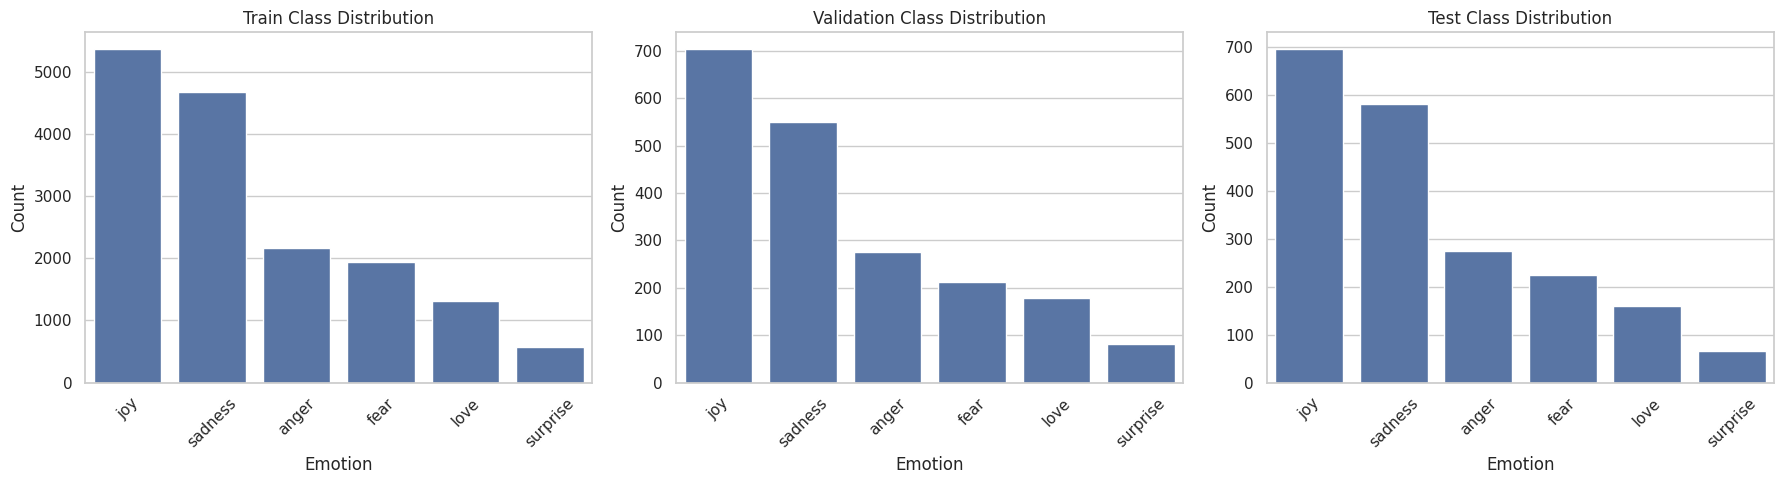

In [8]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df) in zip(
    axes,
    [("Train", train_df), ("Validation", val_df), ("Test", test_df)]
):
    counts = df["label_name"].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title(f"{name} Class Distribution")
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [9]:
# Helper utilities for evaluation and visualization
def evaluate_predictions(y_true, y_pred, label2name_map, title="Evaluation"):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(title)
    print(f"Accuracy     : {acc:.4f}")
    print(f"Macro F1     : {macro_f1:.4f}")
    print(f"Weighted F1  : {weighted_f1:.4f}")
    print("\nClassification Report")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[label2name_map[i] for i in sorted(label2name_map)],
            digits=4
        )
    )

    cm = confusion_matrix(y_true, y_pred, labels=sorted(label2name_map))
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[label2name_map[i] for i in sorted(label2name_map)],
        yticklabels=[label2name_map[i] for i in sorted(label2name_map)],
    )
    plt.title(f"{title} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }

def print_example_predictions(texts, y_true, y_pred, label2name_map, n=10):
    preview_df = pd.DataFrame({
        "text": texts[:n],
        "true_label": [label2name_map[i] for i in y_true[:n]],
        "pred_label": [label2name_map[i] for i in y_pred[:n]],
    })
    display(preview_df)

## 1. From scratch traditional baseline: TF-IDF + Linear SVM

This baseline uses:
- text cleaning for sparse features
- word + bigram TF-IDF
- Linear SVM with balanced class weights

In [10]:
# Text preprocessing for the traditional model
def clean_text_for_tfidf(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["text_tfidf"] = train_df["text"].apply(clean_text_for_tfidf)
val_df["text_tfidf"] = val_df["text"].apply(clean_text_for_tfidf)
test_df["text_tfidf"] = test_df["text"].apply(clean_text_for_tfidf)

display(train_df[["text", "text_tfidf"]].head())

,text,text_tfidf
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,i am feeling grouchy


Validation - TF-IDF + Linear SVM
Accuracy     : 0.9035
Macro F1     : 0.8738
Weighted F1  : 0.9037

Classification Report
              precision    recall  f1-score   support

     sadness     0.9275    0.9309    0.9292       550
         joy     0.9272    0.9233    0.9253       704
        love     0.8041    0.8764    0.8387       178
       anger     0.9219    0.9018    0.9118       275
        fear     0.8806    0.8349    0.8571       212
    surprise     0.7711    0.7901    0.7805        81

    accuracy                         0.9035      2000
   macro avg     0.8721    0.8762    0.8738      2000
weighted avg     0.9044    0.9035    0.9037      2000



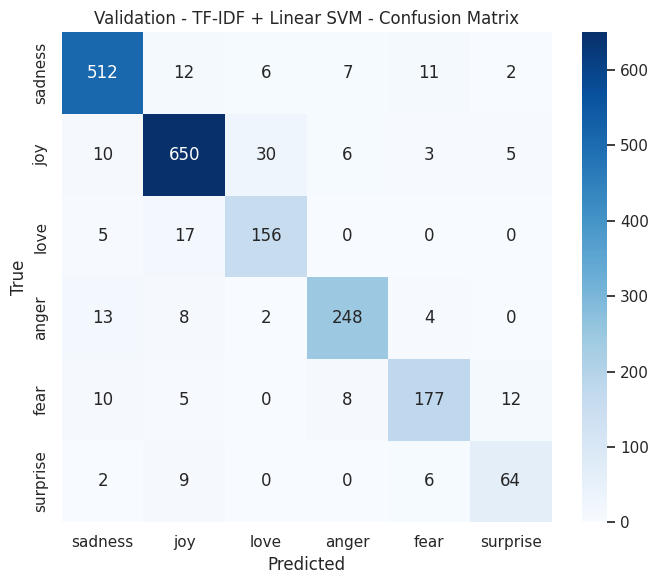

In [11]:
# Train the TF-IDF + SVM model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

svm_ngram_range = (1, 2)
svm_min_df = 2
svm_max_df = 0.98
svm_c = 1.0

svm_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=False,
            ngram_range=svm_ngram_range,
            min_df=svm_min_df,
            max_df=svm_max_df,
            sublinear_tf=True,
            strip_accents="unicode",
        ),
    ),
    (
        "clf",
        LinearSVC(
            C=svm_c,
            class_weight="balanced",
            random_state=SEED,
        ),
    ),
])

svm_pipeline.fit(train_df["text_tfidf"], train_df["label"])

val_pred_svm = svm_pipeline.predict(val_df["text_tfidf"])
svm_val_metrics = evaluate_predictions(
    val_df["label"],
    val_pred_svm,
    label2name,
    title="Validation - TF-IDF + Linear SVM"
)

Test - TF-IDF + Linear SVM
Accuracy     : 0.8870
Macro F1     : 0.8395
Weighted F1  : 0.8880

Classification Report
              precision    recall  f1-score   support

     sadness     0.9288    0.9208    0.9248       581
         joy     0.9239    0.9079    0.9158       695
        love     0.7222    0.8176    0.7670       159
       anger     0.8873    0.8873    0.8873       275
        fear     0.8732    0.8304    0.8513       224
    surprise     0.6575    0.7273    0.6906        66

    accuracy                         0.8870      2000
   macro avg     0.8322    0.8485    0.8395      2000
weighted avg     0.8898    0.8870    0.8880      2000



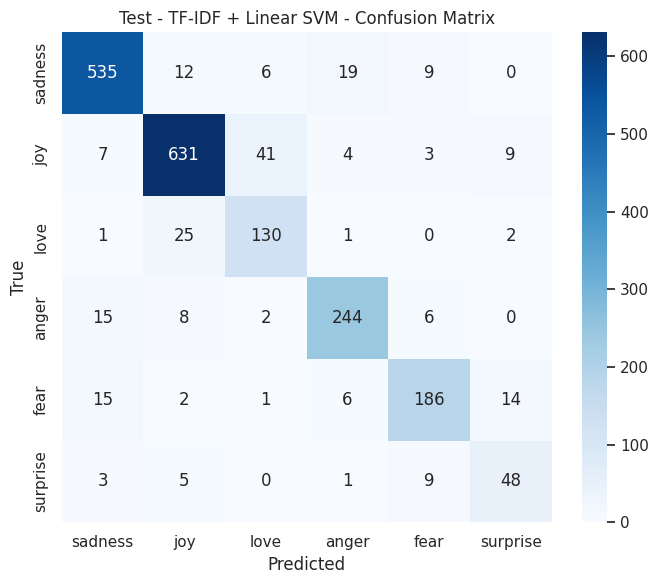

,text,true_label,pred_label
0,im feeling rather rotten so im not very ambiti...,sadness,sadness
1,im updating my blog because i feel shitty,sadness,sadness
2,i never make her separate from me because i do...,sadness,sadness
3,i left with my bouquet of red and yellow tulip...,joy,joy
4,i was feeling a little vain when i did this one,sadness,sadness
5,i cant walk into a shop anywhere where i do no...,fear,fear
6,i felt anger when at the end of a telephone call,anger,anger
7,i explain why i clung to a relationship with a...,joy,joy
8,i like to have the same breathless feeling as ...,joy,joy
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger


In [12]:
# Test set evaluation for SVM
test_pred_svm = svm_pipeline.predict(test_df["text_tfidf"])
svm_test_metrics = evaluate_predictions(
    test_df["label"],
    test_pred_svm,
    label2name,
    title="Test - TF-IDF + Linear SVM"
)

print_example_predictions(
    test_df["text"].tolist(),
    test_df["label"].tolist(),
    test_pred_svm.tolist(),
    label2name,
    n=10
)

In [13]:
# Save the traditional model
import joblib

svm_save_dir = Path("/kaggle/working/svm_tfidf_model")
svm_save_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(svm_pipeline, svm_save_dir / "svm_tfidf_pipeline.joblib")
print("Saved to:", svm_save_dir / "svm_tfidf_pipeline.joblib")

Saved to: /kaggle/working/svm_tfidf_model/svm_tfidf_pipeline.joblib


## 2. From scratch deep learning baseline: BiLSTM

This model uses:
- a custom text standardization function
- `TextVectorization`
- trainable embedding layer
- stacked bidirectional LSTM layers

In [14]:
# TensorFlow / Keras imports
import tensorflow as tf
from tensorflow.keras import layers, callbacks, Model

tf.keras.utils.set_random_seed(SEED)
print("TensorFlow version:", tf.__version__)

2026-04-01 15:28:26.479192: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775057306.876632      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775057306.990682      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775057307.964270      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775057307.964310      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775057307.964313      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [15]:
# Text standardization for the BiLSTM pipeline
def clean_text_for_bilstm(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " user ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_text_bilstm = train_df["text"].apply(clean_text_for_bilstm).values
val_text_bilstm = val_df["text"].apply(clean_text_for_bilstm).values
test_text_bilstm = test_df["text"].apply(clean_text_for_bilstm).values

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

print(train_text_bilstm[:3])

['i didnt feel humiliated'
 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'
 'im grabbing a minute to post i feel greedy wrong']


In [16]:
# BiLSTM configuration
bilstm_max_tokens = 30000
bilstm_seq_length = 60
bilstm_embedding_dim = 200
bilstm_batch_size = 256
bilstm_epochs = 15
bilstm_learning_rate = 1e-3

text_vectorizer = layers.TextVectorization(
    max_tokens=bilstm_max_tokens,
    output_mode="int",
    output_sequence_length=bilstm_seq_length,
)

text_vectorizer.adapt(train_text_bilstm)

vocab_size = len(text_vectorizer.get_vocabulary())
print("Vocabulary size:", vocab_size)

I0000 00:00:1775057342.584459      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775057342.590300      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Vocabulary size: 15213


In [17]:
# Prepare TensorFlow datasets
AUTOTUNE = tf.data.AUTOTUNE

train_ds_bilstm = tf.data.Dataset.from_tensor_slices((train_text_bilstm, y_train))
val_ds_bilstm = tf.data.Dataset.from_tensor_slices((val_text_bilstm, y_val))
test_ds_bilstm = tf.data.Dataset.from_tensor_slices((test_text_bilstm, y_test))

train_ds_bilstm = train_ds_bilstm.shuffle(len(train_text_bilstm), seed=SEED).batch(bilstm_batch_size).prefetch(AUTOTUNE)
val_ds_bilstm = val_ds_bilstm.batch(bilstm_batch_size).prefetch(AUTOTUNE)
test_ds_bilstm = test_ds_bilstm.batch(bilstm_batch_size).prefetch(AUTOTUNE)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {i: w for i, w in enumerate(class_weights_array)}
class_weights_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [18]:
# Build the BiLSTM model
inputs = layers.Input(shape=(1,), dtype=tf.string)

x = text_vectorizer(inputs)
x = layers.Embedding(input_dim=vocab_size, output_dim=bilstm_embedding_dim, mask_zero=True)(x)
x = layers.SpatialDropout1D(0.25)(x)
x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(len(label2name), activation="softmax")(x)

bilstm_model = Model(inputs, outputs)
bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=bilstm_learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

bilstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 60)        │          0 │ input_layer[0][0] │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 60, 200)   │  3,042,600 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 60, 200)   │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 60)        │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 60, 256)   │    336,896 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │    164,352 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 6)         │        774 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,561,134 (13.58 MB)

 Trainable params: 3,561,134 (13.58 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Train the BiLSTM model
bilstm_save_dir = Path("/kaggle/working/bilstm_model")
bilstm_save_dir.mkdir(parents=True, exist_ok=True)

bilstm_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=str(bilstm_save_dir / "best_bilstm.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
]

history_bilstm = bilstm_model.fit(
    train_ds_bilstm,
    validation_data=val_ds_bilstm,
    epochs=bilstm_epochs,
    class_weight=class_weights_dict,
    callbacks=bilstm_callbacks,
    verbose=1,
)

Epoch 1/15


I0000 00:00:1775057350.558158     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2648 - loss: 1.7541
Epoch 1: val_loss improved from inf to 1.01860, saving model to /kaggle/working/bilstm_model/best_bilstm.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.2691 - loss: 1.7481 - val_accuracy: 0.6475 - val_loss: 1.0186 - learning_rate: 0.0010
Epoch 2/15
62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7556 - loss: 0.6731
Epoch 2: val_loss improved from 1.01860 to 0.46849, saving model to /kaggle/working/bilstm_model/best_bilstm.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7572 - loss: 0.6691 - val_accuracy: 0.8525 - val_loss: 0.4685 - learning_rate: 0.0010
Epoch 3/15
62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9231 - loss: 0.2106
Epoch 3: val_loss improved from 0.46849 to 0.41222, saving model to /kaggle/working/bilstm_model/best_bilstm.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9232 - loss: 0.2106 - val_accuracy: 0.8725 - val_loss: 0.4122 - learning_rate: 0.

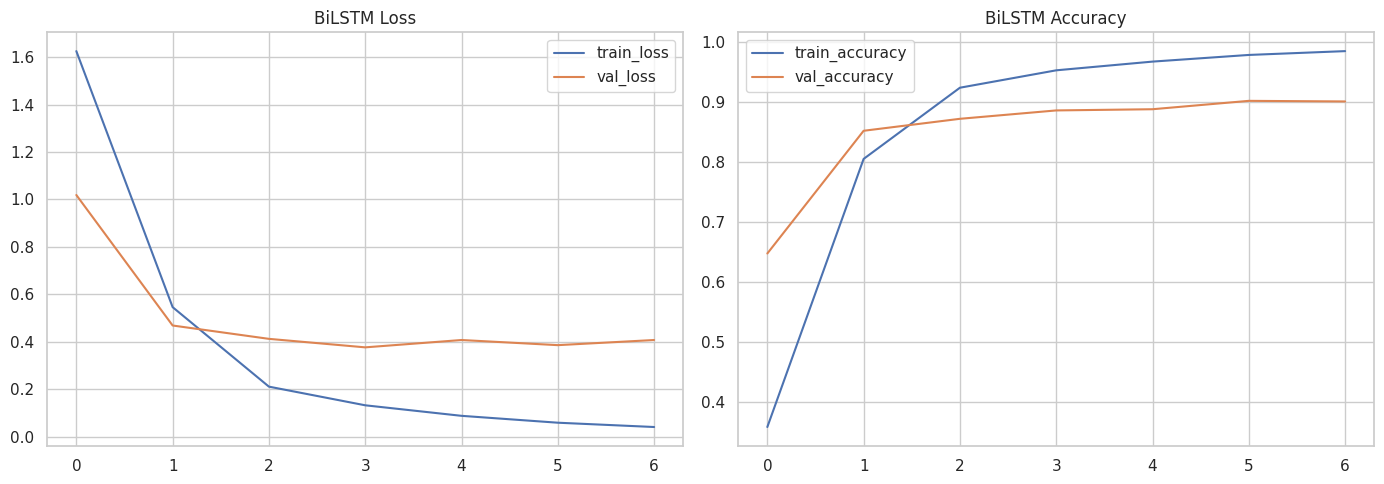

In [20]:
# Plot BiLSTM training curves
history_df = pd.DataFrame(history_bilstm.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["loss"], label="train_loss")
axes[0].plot(history_df["val_loss"], label="val_loss")
axes[0].set_title("BiLSTM Loss")
axes[0].legend()

axes[1].plot(history_df["accuracy"], label="train_accuracy")
axes[1].plot(history_df["val_accuracy"], label="val_accuracy")
axes[1].set_title("BiLSTM Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

Validation - BiLSTM
Accuracy     : 0.8865
Macro F1     : 0.8639
Weighted F1  : 0.8874

Classification Report
              precision    recall  f1-score   support

     sadness     0.8920    0.9309    0.9110       550
         joy     0.9450    0.8778    0.9102       704
        love     0.7512    0.9157    0.8253       178
       anger     0.9206    0.8436    0.8805       275
        fear     0.8357    0.8396    0.8376       212
    surprise     0.7778    0.8642    0.8187        81

    accuracy                         0.8865      2000
   macro avg     0.8537    0.8787    0.8639      2000
weighted avg     0.8914    0.8865    0.8874      2000



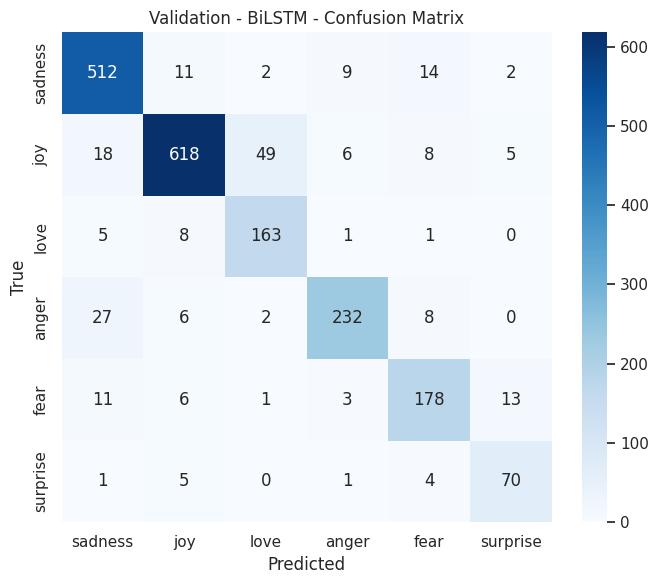

Test - BiLSTM
Accuracy     : 0.8825
Macro F1     : 0.8491
Weighted F1  : 0.8844

Classification Report
              precision    recall  f1-score   support

     sadness     0.9099    0.9208    0.9153       581
         joy     0.9470    0.8734    0.9087       695
        love     0.6869    0.9245    0.7882       159
       anger     0.8945    0.8327    0.8625       275
        fear     0.8649    0.8571    0.8610       224
    surprise     0.6962    0.8333    0.7586        66

    accuracy                         0.8825      2000
   macro avg     0.8332    0.8737    0.8491      2000
weighted avg     0.8908    0.8825    0.8844      2000



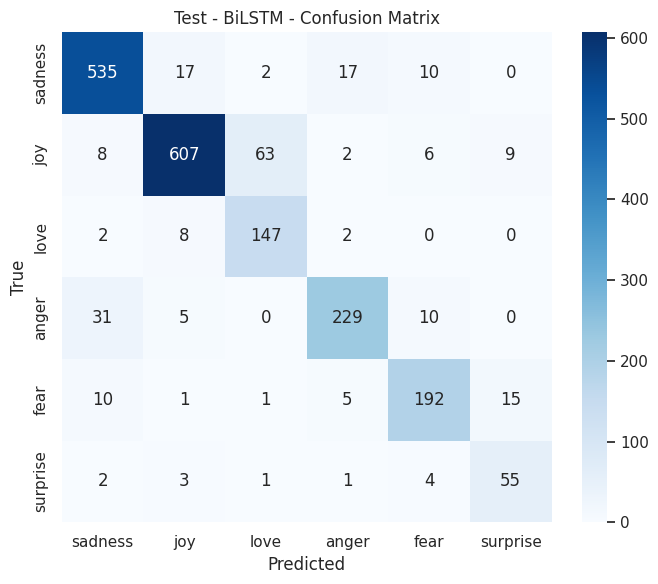

In [21]:
# Evaluate the BiLSTM model
val_probs_bilstm = bilstm_model.predict(val_ds_bilstm, verbose=0)
val_pred_bilstm = np.argmax(val_probs_bilstm, axis=1)

bilstm_val_metrics = evaluate_predictions(
    y_val,
    val_pred_bilstm,
    label2name,
    title="Validation - BiLSTM"
)

test_probs_bilstm = bilstm_model.predict(test_ds_bilstm, verbose=0)
test_pred_bilstm = np.argmax(test_probs_bilstm, axis=1)

bilstm_test_metrics = evaluate_predictions(
    y_test,
    test_pred_bilstm,
    label2name,
    title="Test - BiLSTM"
)

In [22]:
# Save the BiLSTM model
final_bilstm_path = bilstm_save_dir / "final_bilstm.keras"
bilstm_model.save(final_bilstm_path)
print("Saved to:", final_bilstm_path)

Saved to: /kaggle/working/bilstm_model/final_bilstm.keras


## 3. Fine-tuned BERTweet

BERTweet is a tweet-specialized transformer, so it is a strong fit for English Twitter-style text.

In [23]:
# PyTorch / Transformers imports
import torch
import evaluate

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [24]:
# Build a Hugging Face DatasetDict
hf_ds = DatasetDict({
    "train": Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False),
    "validation": Dataset.from_pandas(val_df[["text", "label"]], preserve_index=False),
    "test": Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False),
})

hf_ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [25]:
# BERTweet configuration
bertweet_model_name = "vinai/bertweet-base"
bertweet_max_length = 128
bertweet_batch_size = 32
bertweet_learning_rate = 2e-5
bertweet_epochs = 3
bertweet_weight_decay = 0.01

tokenizer = AutoTokenizer.from_pretrained(
    bertweet_model_name,
    use_fast=False,
    normalization=True,
)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=bertweet_max_length,
        padding=False,
    )

tokenized_ds = hf_ds.map(tokenize_batch, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    accuracy = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    macro_f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    weighted_f1 = f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"]

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [26]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# Initialize the BERTweet classifier
bertweet_model = AutoModelForSequenceClassification.from_pretrained(
    bertweet_model_name,
    num_labels=len(label2name),
    id2label=label2name,
    label2id=name2label,
)

bertweet_output_dir = "/kaggle/working/bertweet_baseline"

bertweet_training_args = TrainingArguments(
    output_dir=bertweet_output_dir,
    learning_rate=bertweet_learning_rate,
    per_device_train_batch_size=bertweet_batch_size,
    per_device_eval_batch_size=bertweet_batch_size,
    num_train_epochs=bertweet_epochs,
    weight_decay=bertweet_weight_decay,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

bertweet_trainer = Trainer(
    model=bertweet_model,
    args=bertweet_training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

In [27]:
# Train BERTweet
bertweet_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.448600,0.354499,0.918000,0.888803,0.917330
2,0.239800,0.225688,0.925500,0.896824,0.925368
3,0.191500,0.204746,0.931000,0.903933,0.931222


TrainOutput(global_step=750, training_loss=0.46185575612386065, metrics={'train_runtime': 335.982, 'train_samples_per_second': 142.865, 'train_steps_per_second': 2.232, 'total_flos': 1363227335534592.0, 'train_loss': 0.46185575612386065, 'epoch': 3.0})

In [28]:
# Evaluate BERTweet on validation and test
bertweet_val_metrics = bertweet_trainer.evaluate(tokenized_ds["validation"])
print("Validation metrics:", bertweet_val_metrics)

bertweet_test_metrics = bertweet_trainer.evaluate(tokenized_ds["test"])
print("Test metrics:", bertweet_test_metrics)

Validation metrics: {'eval_loss': 0.20474591851234436, 'eval_accuracy': 0.931, 'eval_macro_f1': 0.9039328386319765, 'eval_weighted_f1': 0.931221822607816, 'eval_runtime': 4.5026, 'eval_samples_per_second': 444.184, 'eval_steps_per_second': 7.107, 'epoch': 3.0}
Test metrics: {'eval_loss': 0.19164764881134033, 'eval_accuracy': 0.9245, 'eval_macro_f1': 0.8835650689208275, 'eval_weighted_f1': 0.9244427447270281, 'eval_runtime': 4.3988, 'eval_samples_per_second': 454.669, 'eval_steps_per_second': 7.275, 'epoch': 3.0}


Test - Fine-tuned BERTweet
Accuracy     : 0.9245
Macro F1     : 0.8836
Weighted F1  : 0.9244

Classification Report
              precision    recall  f1-score   support

     sadness     0.9475    0.9639    0.9556       581
         joy     0.9577    0.9453    0.9515       695
        love     0.8303    0.8616    0.8457       159
       anger     0.9283    0.8945    0.9111       275
        fear     0.8664    0.8973    0.8816       224
    surprise     0.7869    0.7273    0.7559        66

    accuracy                         0.9245      2000
   macro avg     0.8862    0.8817    0.8836      2000
weighted avg     0.9247    0.9245    0.9244      2000



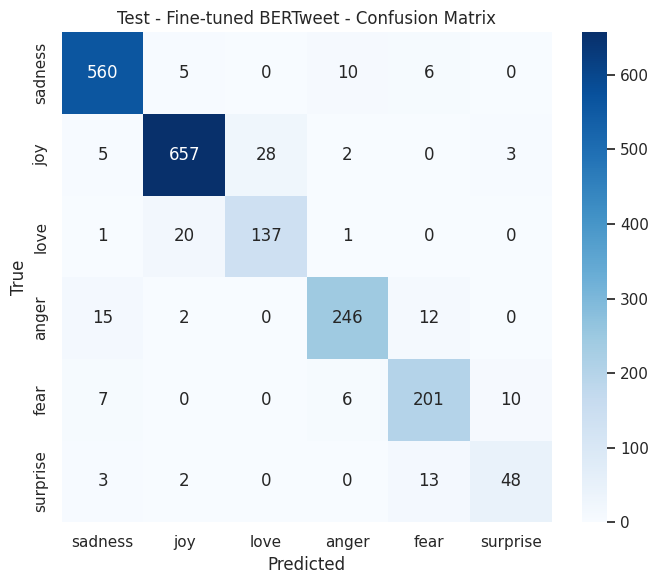

In [29]:
# Detailed test evaluation for BERTweet
bertweet_test_output = bertweet_trainer.predict(tokenized_ds["test"])
bertweet_test_preds = np.argmax(bertweet_test_output.predictions, axis=1)

bertweet_final_test_metrics = evaluate_predictions(
    test_df["label"].values,
    bertweet_test_preds,
    label2name,
    title="Test - Fine-tuned BERTweet"
)

In [30]:
# Save the fine-tuned BERTweet model
bertweet_save_dir = Path("/kaggle/working/bertweet_baseline_final")
bertweet_save_dir.mkdir(parents=True, exist_ok=True)

bertweet_trainer.save_model(str(bertweet_save_dir))
tokenizer.save_pretrained(str(bertweet_save_dir))

print("Saved to:", bertweet_save_dir)

Saved to: /kaggle/working/bertweet_baseline_final


## 4. Fine-tuned BERTweet + Supervised Contrastive Learning

This section adds a supervised contrastive objective on top of the usual cross-entropy loss.

Training objective:
`total_loss = cross_entropy + alpha * supervised_contrastive_loss`

In [31]:
# Prepare PyTorch datasets and dataloaders for the supervised contrastive experiment
from torch.utils.data import Dataset as TorchDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

class TweetTorchDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
            padding=False,
        )
        encoded["labels"] = self.labels[idx]
        return encoded

supcon_max_length = 128
supcon_batch_size = 32

train_torch_ds = TweetTorchDataset(train_df["text"], train_df["label"], tokenizer, supcon_max_length)
val_torch_ds = TweetTorchDataset(val_df["text"], val_df["label"], tokenizer, supcon_max_length)
test_torch_ds = TweetTorchDataset(test_df["text"], test_df["label"], tokenizer, supcon_max_length)

supcon_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_loader = DataLoader(
    train_torch_ds,
    batch_size=supcon_batch_size,
    shuffle=True,
    collate_fn=supcon_collator,
    num_workers=0,
    pin_memory=True,
)
val_loader = DataLoader(
    val_torch_ds,
    batch_size=supcon_batch_size,
    shuffle=False,
    collate_fn=supcon_collator,
    num_workers=0,
    pin_memory=True,
)
test_loader = DataLoader(
    test_torch_ds,
    batch_size=supcon_batch_size,
    shuffle=False,
    collate_fn=supcon_collator,
    num_workers=0,
    pin_memory=True,
)

len(train_loader), len(val_loader), len(test_loader)

(500, 63, 63)

In [32]:
# Define the BERTweet + SupCon model
from transformers import AutoModel

class BertweetSupConClassifier(nn.Module):
    def __init__(self, model_name, num_labels, proj_dim=128, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels)

        self.projection = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, proj_dim),
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        cls_embedding = outputs.last_hidden_state[:, 0]
        cls_embedding = self.dropout(cls_embedding)

        logits = self.classifier(cls_embedding)
        projected = self.projection(cls_embedding)
        projected = F.normalize(projected, p=2, dim=1)

        return logits, projected

In [33]:
# Supervised contrastive loss
def supervised_contrastive_loss(features, labels, temperature=0.1, eps=1e-8):
    labels = labels.contiguous().view(-1, 1)
    batch_size = features.size(0)
    device = features.device

    mask = torch.eq(labels, labels.T).float().to(device)

    logits = torch.matmul(features, features.T) / temperature
    logits_max, _ = torch.max(logits, dim=1, keepdim=True)
    logits = logits - logits_max.detach()

    logits_mask = torch.ones_like(mask) - torch.eye(batch_size, device=device)
    mask = mask * logits_mask

    exp_logits = torch.exp(logits) * logits_mask
    log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + eps)

    positive_counts = mask.sum(dim=1)
    positive_counts = torch.clamp(positive_counts, min=1.0)

    mean_log_prob_pos = (mask * log_prob).sum(dim=1) / positive_counts
    loss = -mean_log_prob_pos.mean()

    return loss

In [34]:
# Training configuration for BERTweet + SupCon
supcon_model_name = "vinai/bertweet-base"
supcon_num_labels = len(label2name)
supcon_proj_dim = 128
supcon_dropout = 0.1

supcon_epochs = 3
supcon_learning_rate = 2e-5
supcon_weight_decay = 0.01
supcon_alpha = 0.2
supcon_temperature = 0.1
supcon_grad_clip = 1.0
supcon_label_smoothing = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

supcon_model = BertweetSupConClassifier(
    model_name=supcon_model_name,
    num_labels=supcon_num_labels,
    proj_dim=supcon_proj_dim,
    dropout=supcon_dropout,
).to(device)

optimizer = torch.optim.AdamW(
    supcon_model.parameters(),
    lr=supcon_learning_rate,
    weight_decay=supcon_weight_decay,
)

num_training_steps = supcon_epochs * len(train_loader)
num_warmup_steps = int(0.1 * num_training_steps)

from transformers import get_linear_schedule_with_warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
print("Device:", device)

Device: cuda


In [35]:
# Training and evaluation utilities
def compute_epoch_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

def train_one_epoch_supcon(model, loader, optimizer, scheduler, scaler, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for batch in progress_bar:
        labels = batch["labels"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits, features = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )

            ce_loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=supcon_label_smoothing
            )
            scl_loss = supervised_contrastive_loss(
                features,
                labels,
                temperature=supcon_temperature
            )
            loss = ce_loss + supcon_alpha * scl_loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), supcon_grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item()
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_loss = running_loss / len(loader)
    metrics = compute_epoch_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss
    return metrics

@torch.no_grad()
def evaluate_supcon(model, loader, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        labels = batch["labels"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits, features = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )

            ce_loss = F.cross_entropy(
                logits,
                labels,
                label_smoothing=supcon_label_smoothing
            )
            scl_loss = supervised_contrastive_loss(
                features,
                labels,
                temperature=supcon_temperature
            )
            loss = ce_loss + supcon_alpha * scl_loss

        running_loss += loss.item()
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader)
    metrics = compute_epoch_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss
    metrics["preds"] = all_preds
    metrics["labels"] = all_labels
    return metrics

In [36]:
# Train BERTweet + SupCon without early stopping
supcon_save_dir = Path("/kaggle/working/bertweet_supcon")
supcon_save_dir.mkdir(parents=True, exist_ok=True)

supcon_history = []

for epoch in range(1, supcon_epochs + 1):
    print(f"\nEpoch {epoch}/{supcon_epochs}")

    train_metrics = train_one_epoch_supcon(
        supcon_model,
        train_loader,
        optimizer,
        scheduler,
        scaler,
        device,
    )

    val_metrics = evaluate_supcon(
        supcon_model,
        val_loader,
        device,
    )

    epoch_record = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
    }
    supcon_history.append(epoch_record)

    print(json.dumps(epoch_record, indent=2))

# Save the last-epoch model
final_model_path = supcon_save_dir / "bertweet_supcon_last_epoch_state_dict.pth"
torch.save(supcon_model.state_dict(), final_model_path)

# Save a full checkpoint
final_checkpoint_path = supcon_save_dir / "bertweet_supcon_last_epoch_checkpoint.pth"
torch.save(
    {
        "epoch": supcon_epochs,
        "model_state_dict": supcon_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "history": supcon_history,
    },
    final_checkpoint_path,
)

print(f"\nFinal model state_dict saved to: {final_model_path}")
print(f"Final checkpoint saved to: {final_checkpoint_path}")


Epoch 1/3


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

{
  "epoch": 1,
  "train_loss": 1.4640609166622163,
  "train_accuracy": 0.7171875,
  "train_macro_f1": 0.6226730663145165,
  "val_loss": 0.8799089524481032,
  "val_accuracy": 0.9245,
  "val_macro_f1": 0.897690605335363,
  "val_weighted_f1": 0.9245742306695608
}

Epoch 2/3


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

{
  "epoch": 2,
  "train_loss": 0.8201764642000199,
  "train_accuracy": 0.93225,
  "train_macro_f1": 0.8991936268041808,
  "val_loss": 0.8066213282327803,
  "val_accuracy": 0.932,
  "val_macro_f1": 0.9056308355953662,
  "val_weighted_f1": 0.9318785605077357
}

Epoch 3/3


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

{
  "epoch": 3,
  "train_loss": 0.7473506842851638,
  "train_accuracy": 0.949,
  "train_macro_f1": 0.9205345487534718,
  "val_loss": 0.8005453792829362,
  "val_accuracy": 0.9345,
  "val_macro_f1": 0.9086523270345178,
  "val_weighted_f1": 0.9349359057765269
}

Final model state_dict saved to: /kaggle/working/bertweet_supcon/bertweet_supcon_last_epoch_state_dict.pth
Final checkpoint saved to: /kaggle/working/bertweet_supcon/bertweet_supcon_last_epoch_checkpoint.pth


,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,val_weighted_f1
0,1,1.464061,0.717187,0.622673,0.879909,0.9245,0.897691,0.924574
1,2,0.820176,0.932250,0.899194,0.806621,0.9320,0.905631,0.931879
2,3,0.747351,0.949000,0.920535,0.800545,0.9345,0.908652,0.934936


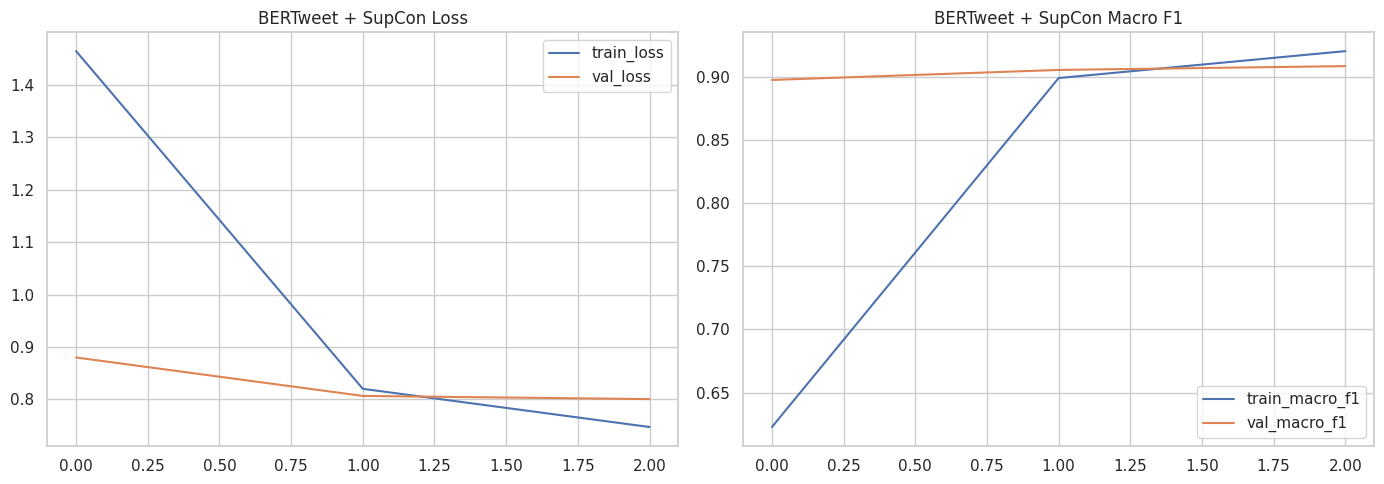

In [37]:
# Plot training history for BERTweet + SupCon
supcon_history_df = pd.DataFrame(supcon_history)
display(supcon_history_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(supcon_history_df["train_loss"], label="train_loss")
axes[0].plot(supcon_history_df["val_loss"], label="val_loss")
axes[0].set_title("BERTweet + SupCon Loss")
axes[0].legend()

axes[1].plot(supcon_history_df["train_macro_f1"], label="train_macro_f1")
axes[1].plot(supcon_history_df["val_macro_f1"], label="val_macro_f1")
axes[1].set_title("BERTweet + SupCon Macro F1")
axes[1].legend()

plt.tight_layout()
plt.show()

In [38]:
# Evaluate the last-epoch model
supcon_model.load_state_dict(torch.load(final_model_path, map_location=device, weights_only=True))
supcon_model.to(device)
supcon_model.eval()

supcon_val_metrics = evaluate_supcon(supcon_model, val_loader, device)
print("Validation metrics:", {k: v for k, v in supcon_val_metrics.items() if k not in ["preds", "labels"]})

supcon_test_metrics = evaluate_supcon(supcon_model, test_loader, device)
print("Test metrics:", {k: v for k, v in supcon_test_metrics.items() if k not in ["preds", "labels"]})

Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

Validation metrics: {'accuracy': 0.9345, 'macro_f1': 0.9086523270345178, 'weighted_f1': 0.9349359057765269, 'loss': 0.8005453792829362}


Evaluating:   0%|          | 0/63 [00:00<?, ?it/s]

Test metrics: {'accuracy': 0.9295, 'macro_f1': 0.8850249538056075, 'weighted_f1': 0.9301092121927808, 'loss': 0.7941545844078064}


Test - Fine-tuned BERTweet + Supervised Contrastive
Accuracy     : 0.9295
Macro F1     : 0.8850
Weighted F1  : 0.9301

Classification Report
              precision    recall  f1-score   support

     sadness     0.9623    0.9673    0.9648       581
         joy     0.9649    0.9482    0.9565       695
        love     0.8415    0.8679    0.8545       159
       anger     0.9299    0.9164    0.9231       275
        fear     0.8829    0.8750    0.8789       224
    surprise     0.6842    0.7879    0.7324        66

    accuracy                         0.9295      2000
   macro avg     0.8776    0.8938    0.8850      2000
weighted avg     0.9311    0.9295    0.9301      2000



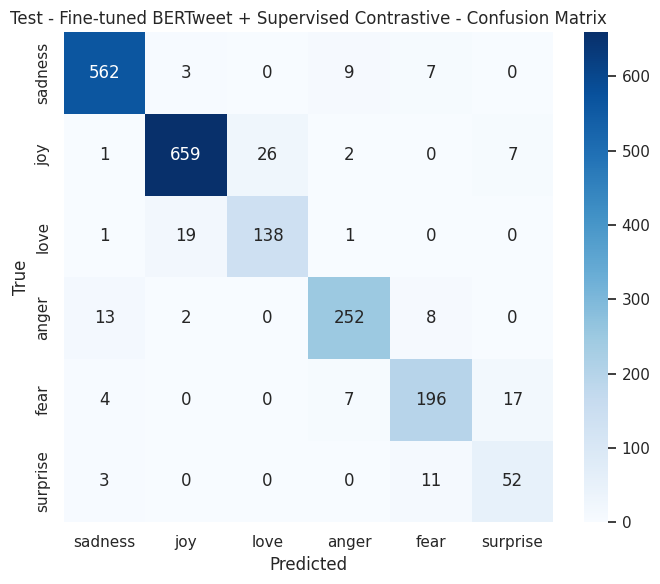

In [39]:
# Detailed test evaluation for BERTweet + SupCon
supcon_final_test_metrics = evaluate_predictions(
    supcon_test_metrics["labels"],
    supcon_test_metrics["preds"],
    label2name,
    title="Test - Fine-tuned BERTweet + Supervised Contrastive"
)

In [40]:
# Save tokenizer and config
tokenizer.save_pretrained(supcon_save_dir)

supcon_config = {
    "model_name": supcon_model_name,
    "num_labels": supcon_num_labels,
    "proj_dim": supcon_proj_dim,
    "dropout": supcon_dropout,
    "max_length": supcon_max_length,
    "label2name": label2name,
}
with open(supcon_save_dir / "config.json", "w") as f:
    json.dump(supcon_config, f, indent=2)

print("Saved to:", supcon_save_dir)

Saved to: /kaggle/working/bertweet_supcon


In [41]:
# Final comparison table
comparison_rows = [
    {
        "model": "TF-IDF + Linear SVM",
        "accuracy": svm_test_metrics["accuracy"],
        "macro_f1": svm_test_metrics["macro_f1"],
        "weighted_f1": svm_test_metrics["weighted_f1"],
    },
    {
        "model": "BiLSTM",
        "accuracy": bilstm_test_metrics["accuracy"],
        "macro_f1": bilstm_test_metrics["macro_f1"],
        "weighted_f1": bilstm_test_metrics["weighted_f1"],
    },
    {
        "model": "BERTweet",
        "accuracy": bertweet_final_test_metrics["accuracy"],
        "macro_f1": bertweet_final_test_metrics["macro_f1"],
        "weighted_f1": bertweet_final_test_metrics["weighted_f1"],
    },
    {
        "model": "BERTweet + SupCon",
        "accuracy": supcon_final_test_metrics["accuracy"],
        "macro_f1": supcon_final_test_metrics["macro_f1"],
        "weighted_f1": supcon_final_test_metrics["weighted_f1"],
    },
]

comparison_df = pd.DataFrame(comparison_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(comparison_df)

,model,accuracy,macro_f1,weighted_f1
0,BERTweet + SupCon,0.9295,0.885025,0.930109
1,BERTweet,0.9245,0.883565,0.924443
2,BiLSTM,0.8825,0.849055,0.884390
3,TF-IDF + Linear SVM,0.8870,0.839461,0.888009


Bibliography:

[1] Gunel, B., Du, J., Conneau, A., & Stoyanov, V. (2020). Supervised contrastive learning for pre-trained language model fine-tuning. arXiv. https://arxiv.org/abs/2011.01403